Tar utgangspunkt i modellen for alkoholinntak fra kap. 2.3

ds/dt = -k_a * S
dB/dt = k_a * S - V_max*B/K_m+B

Bruk paramterveridene for "mann 75 kg" fra notatene.

Intialinnntak S(0) = 35 gram (2 halvlitere pils). B(0) =0
Absorpsjonsrate k_a = 2.8 time^-1
V_max = 7.35 gram/time
K_m = 4.9 gram
Volum for fordeling V_dist = 49 liter

#### Imports

In [47]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

#### Oppgave 7
Implementer modellen ved hjelp av scipy.integrate.solve_ivp
Simuler over et tidsintervall på 10 timer

##### Constants

In [48]:
V_max = 7.35                    # gram/time
k_a = 2.8                       # time^-1
K_m = 4.9                       # gram
V_dist = 49                     # liter

##### Define systems of ODEs

In [49]:
def alchohol_breakdown(t, y):
    S, B = y

    # Rate of change
    dS = -k_a * S
    dB = k_a * S - (V_max * B) / (K_m + B)

    return [dS, dB]

##### Initial conditions

In [50]:
# Set intial conditions
S0 = 35                         # gram
B0 = 0
intial_state = [S0, B0]

#### Soltion

In [51]:
# Set time span (hours)
t_span = (0, 10)                # simulate for 10 hours

# specific time points to evulate the soultion at
t_eval = np.linspace(t_span[0], t_span[1], 100)    

solution = solve_ivp(
    alchohol_breakdown,
    t_span,
    intial_state,
    t_eval=t_eval
)

#### Plot results

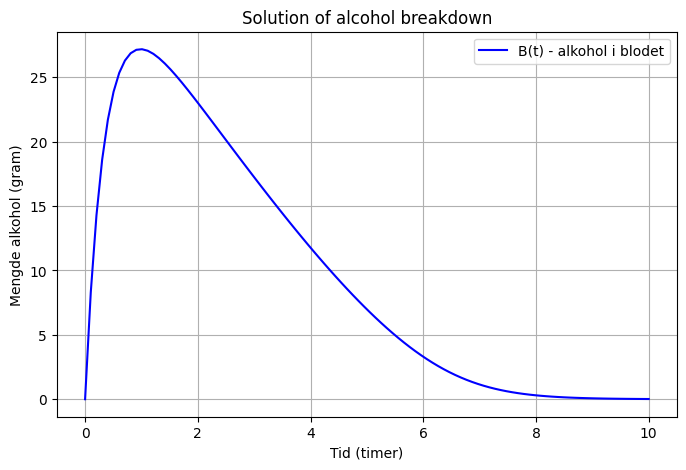

In [52]:
if solution.success:
    t = solution.t
    S = solution.y[0]
    B = solution.y[1]

    plt.figure(figsize=(8,5))
    plt.plot(t, B, 'b-', label='B(t) - alkohol i blodet')
    plt.xlabel('Tid (timer)')
    plt.ylabel('Mengde alkohol (gram)')
    plt.title('Solution of alcohol breakdown')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print(f'Solver terminated with status: {solution.message}')

### Oppgave 8
Plot S(t) og B(t) i samme figur

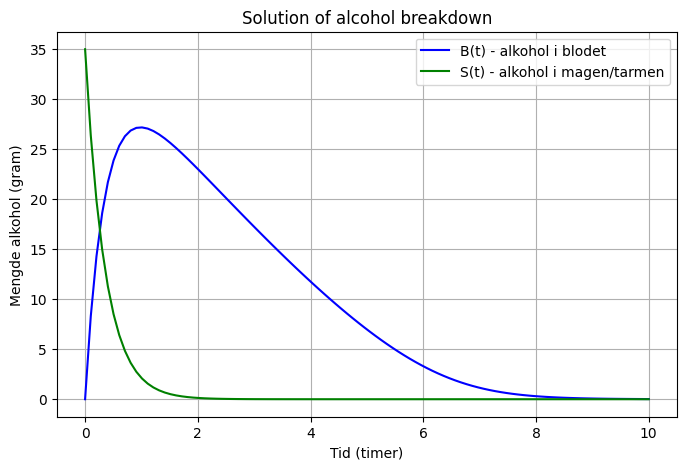

In [53]:
plt.figure(figsize=(8,5))
plt.xlabel('Tid (timer)')
plt.ylabel('Mengde alkohol (gram)')
plt.title('Solution of alcohol breakdown')
plt.grid(True)
plt.plot(t, B, 'b-', label='B(t) - alkohol i blodet')
plt.plot(t, S, 'g-', label='S(t) - alkohol i magen/tarmen')
plt.legend()
plt.show()

### Oppgave 9
Lag et nytt plott som viser promillen som funksjon av tid

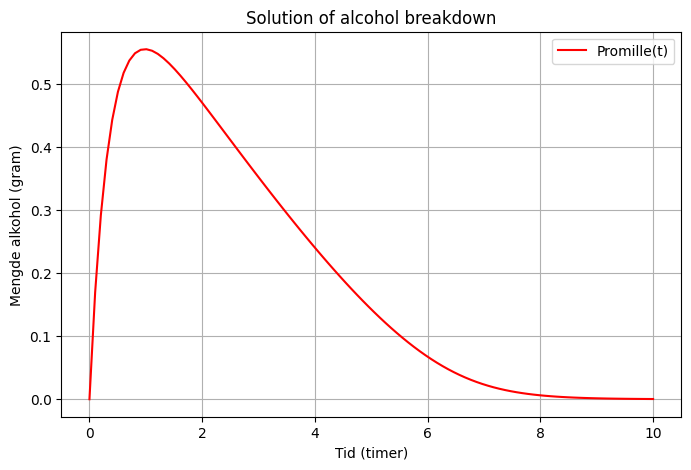

In [54]:
promille = B / V_dist
plt.figure(figsize=(8,5))
plt.xlabel('Tid (timer)')
plt.ylabel('Mengde alkohol (gram)')
plt.title('Solution of alcohol breakdown')
plt.grid(True)
plt.plot(t, promille, 'r-', label='Promille(t)')
plt.legend()
plt.show()

#### 10. Analyse
Hva er den maksimale promillen, og omtrent når inntreffer den?
Hvor lang tid før personen er kjørbar (promillegrense på 0.2)

In [55]:
max_promille = np.argmax(promille)
maksimal_promille = max(promille)

tid_max_promille = t_eval[max_promille]

kjørbar = 0.2

imax = np.argmax(promille)

t_up = np.interp(kjørbar, promille[:imax+1], t[:imax+1])
t_down = np.interp(kjørbar, promille[imax:][::-1], t[imax:][::-1])

print(f"0.2 på vei opp:  {t_up:.2f} timer")
print(f"0.2 på vei ned:  {t_down:.2f} timer")

print(f'Personnen har en maks promille på:  {maksimal_promille:.2f}')
print(f'Personnen har maks promille etter:  {tid_max_promille:.2f} timer')

0.2 på vei opp:  0.13 timer
0.2 på vei ned:  4.39 timer
Personnen har en maks promille på:  0.55
Personnen har maks promille etter:  1.01 timer


#### Oppgave 11
Hva-om scenario.
Anta at personnen drikker på tom mage, slik at absorpsjonen går dobbelt så fort (k_a = 5.6). Sammenling topp promillen. Raskere full, eller fullere?

#### New constants

In [56]:
V_max = 7.35                    # gram/time
k_a = 2.8                       # time^-1
K_m = 4.9                       # gram
V_dist = 49                     # liter

#### Solution

In [57]:
# Set time span (hours)
t_span = (0, 10)                # simulate for 10 hours

# specific time points to evulate the soultion at
t_eval = np.linspace(t_span[0], t_span[1], 100)    

solution_new = solve_ivp(
    alchohol_breakdown,
    t_span,
    intial_state,
    t_eval=t_eval
)

#### Plot

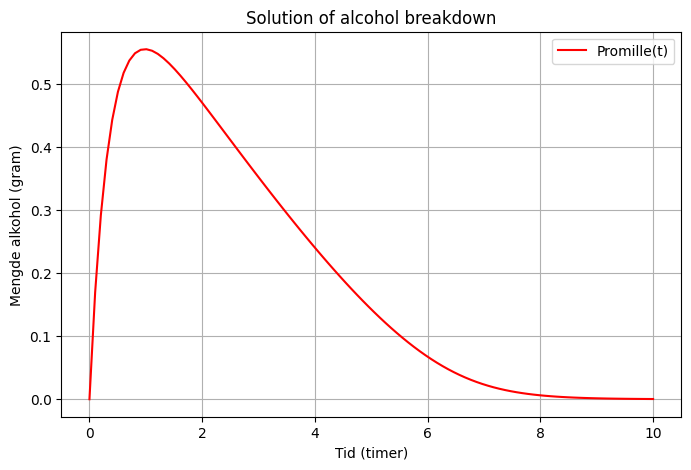

In [65]:
t_new = solution_new.t
S_new = solution_new.y[0]
B_new = solution_new.y[1]

promille_new = B_new / V_dist

plt.figure(figsize=(8,5))
plt.xlabel('Tid (timer)')
plt.ylabel('Mengde alkohol (gram)')
plt.title('Solution of alcohol breakdown')
plt.grid(True)
plt.plot(t_new, promille_new, 'r-', label='Promille(t)')
plt.legend()
plt.show()

#### Max promilla

In [63]:
print(f'Maks promille med tom mage er: {max(promille_new):.2f}')
print(f'Forksjell på maksimal promille med full mage {maksimal_promille - max(promille_new)}')

Maks promille med tom mage er: 0.55
Forksjell på maksimal promille med full mage 0.0
